## **스트레인 게이지(Strain Gage) 실험 결과 분석**

기계시스템공학실험(B) 고체생산 3주차

---
`outer_1kg`: 1kg 추로 측정한 Outer 스트레인 게이지의 데이터

`inner_1kg`: 1kg 추로 측정한 Inner 스트레인 게이지의 데이터

`outer_unknown`: 미지의 추로 측정한 Outer 스트레인 게이지의 데이터

`inner_unknown`: 미지의 추로 측정한 Inner 스트레인 게이지의 데이터
<br><br>

실험 분석을 위해 사용한 라이브러리 및 용도는 다음과 같습니다.


`pandas`: csv 형태의 데이터를 처리하기 위해 사용하였다.

`matplotlib`: Python의 시각화 라이브러리로, 각종 선도(Curve)의 시각화를 위해 사용하였다.

`scipy`: 시계열 데이터의 디노이징을 위해 사용하였다.

<br><br>
이외 자세한 실험 과정 및 결과는 실험 보고서를 참고 바랍니다.

In [75]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

outer_1kg = pd.read_excel("D:/00 기계공학실험/고체 생산/Straingage_outer_1kg.xlsx")
inner_1kg = pd.read_excel("D:/00 기계공학실험/고체 생산/Straingage_inner_1kg.xlsx")
outer_1kg.rename(columns = {'시간 - SC1Mod2/ai1':'시간','진폭 - SC1Mod2/ai1':'진폭'}, inplace=True)
inner_1kg.rename(columns = {'시간 - SC1Mod2/ai3':'시간','진폭 - SC1Mod2/ai3':'진폭'}, inplace=True)

display(outer_1kg.head())
display(inner_1kg.head())

,시간,진폭
0,오후 4:39:54.934 2025-11-03,-0.002063
1,오후 4:39:54.935 2025-11-03,-0.002054
2,오후 4:39:54.936 2025-11-03,-0.002060
3,오후 4:39:54.937 2025-11-03,-0.002053
4,오후 4:39:54.938 2025-11-03,-0.002060


,시간,진폭
0,오후 4:39:56.735 2025-11-03,-0.000111
1,오후 4:39:56.736 2025-11-03,-0.000107
2,오후 4:39:56.737 2025-11-03,-0.000110
3,오후 4:39:56.738 2025-11-03,-0.000117
4,오후 4:39:56.739 2025-11-03,-0.000120


In [76]:
import re
# 정규표현식으로 시간만 추출
def extract_time(time_str):
    if not isinstance(time_str, str):
        return time_str
    match = re.search(r'\d{1,2}:\d{2}:\d{2}\.\d+', time_str)
    if match:
        return match.group(0)
    return time_str

inner_1kg['시간'] = inner_1kg['시간'].apply(extract_time)
print(inner_1kg.info())
inner_1kg.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13099 entries, 0 to 13098
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시간      13099 non-null  object 
 1   진폭      13099 non-null  float64
dtypes: float64(1), object(1)
memory usage: 204.8+ KB
None


,시간,진폭
0,4:39:56.735,-0.000111
1,4:39:56.736,-0.000107
2,4:39:56.737,-0.000110
3,4:39:56.738,-0.000117
4,4:39:56.739,-0.000120


### **1kg 추 측정값 - Inner 스트레인 게이지**

Inner 스트레인 게이지 분석

In [77]:
inner_1kg['시간'] = pd.to_timedelta(inner_1kg['시간']).dt.total_seconds()
inner_1kg['시간'] = inner_1kg['시간'] - inner_1kg['시간'].iloc[0]
inner_1kg['진폭'] = inner_1kg['진폭'].astype(float)

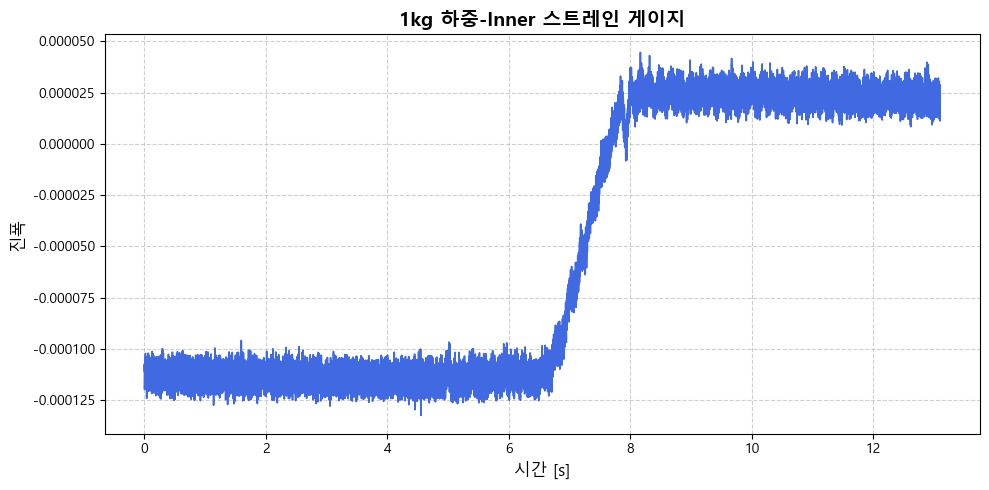

In [78]:
import warnings
warnings.filterwarnings(action = 'ignore')

# 그래프 도식화 (원본raw)
plt.figure(figsize=(10, 5))
plt.plot(inner_1kg['시간'], inner_1kg['진폭'], color='royalblue', linewidth=1.2)

plt.title('1kg 하중-Inner 스트레인 게이지', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]', fontsize=12)
plt.ylabel('진폭', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [79]:
# 전압 평균값 계산
V_unloaded = inner_1kg[(inner_1kg['시간'] >= 0) & (inner_1kg['시간'] <= 5)]['진폭'].mean()
V_loaded = inner_1kg[(inner_1kg['시간'] >= 9) & (inner_1kg['시간'] <= 12)]['진폭'].mean()

print(f"V_unloaded (0~5초 평균) | {V_unloaded:.7f}")
print(f"V_loaded (9~12초 평균)  | {V_loaded:.9f}")

V_unloaded (0~5초 평균) | -0.0001137
V_loaded (9~12초 평균)  | 0.000024059


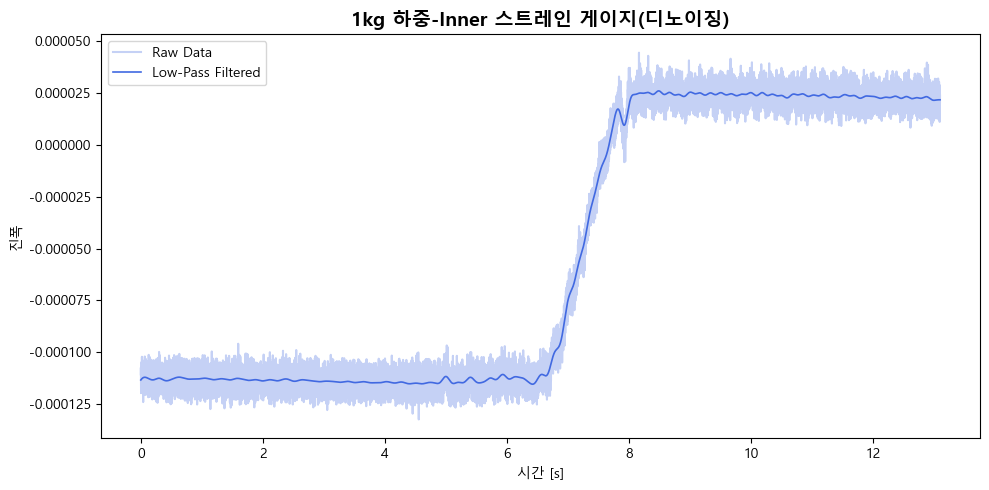

In [80]:
# 로우패스 필터
dt = inner_1kg['시간'].diff().mean()
fs = 1 / dt
cutoff = 5.0
order = 4

nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='low', analog=False)

inner_1kg['진폭_로우패스'] = filtfilt(b, a, inner_1kg['진폭'])

# 2. 그래프 
plt.figure(figsize=(10, 5))
plt.plot(inner_1kg['시간'], inner_1kg['진폭'], color='royalblue', alpha=0.3, label='Raw Data')
plt.plot(inner_1kg['시간'], inner_1kg['진폭_로우패스'], color='royalblue', linewidth=1.2, label='Low-Pass Filtered')

plt.title('1kg 하중-Inner 스트레인 게이지(디노이징)', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]')
plt.ylabel('진폭')
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
# 전압 평균값 계산
V_unloaded = inner_1kg[(inner_1kg['시간'] >= 0) & (inner_1kg['시간'] <= 5)]['진폭_로우패스'].mean()
V_loaded = inner_1kg[(inner_1kg['시간'] >= 9) & (inner_1kg['시간'] <= 12)]['진폭_로우패스'].mean()

print(f"V_unloaded (0~5초, Denoised) | {V_unloaded:.7f}")
print(f"V_loaded (9~12초, Denoised)  | {V_loaded:.9f}")
print(f"delta_V                      | {V_loaded-V_unloaded:.9f}")

V_unloaded (0~5초, Denoised) | -0.0001137
V_loaded (9~12초, Denoised)  | 0.000024070
delta_V                      | 0.000137755


### **1kg 추 측정값 - Outer 스트레인 게이지**

Outer 스트레인 게이지 분석

In [82]:
outer_1kg['시간'] = outer_1kg['시간'].apply(extract_time)
outer_1kg['시간'] = pd.to_timedelta(outer_1kg['시간']).dt.total_seconds()
outer_1kg['시간'] = outer_1kg['시간'] - outer_1kg['시간'].iloc[0]
outer_1kg['진폭'] = outer_1kg['진폭'].astype(float)

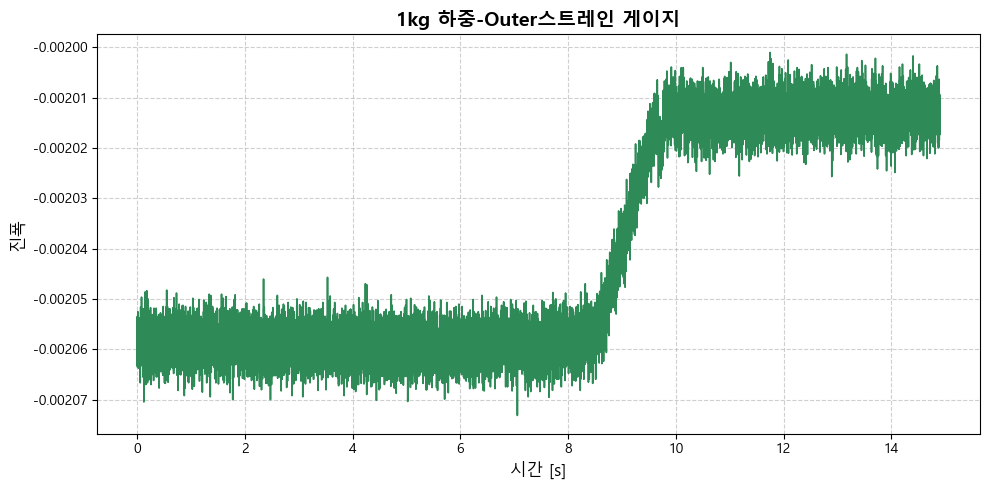

In [83]:
# 그래프(원본raw)
plt.figure(figsize=(10, 5))
plt.plot(outer_1kg['시간'], outer_1kg['진폭'], color='seagreen', linewidth=1.2)

plt.title('1kg 하중-Outer스트레인 게이지', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]', fontsize=12)
plt.ylabel('진폭', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [84]:
# 평균값 계산
V_unloaded = outer_1kg[(outer_1kg['시간'] >= 0) & (outer_1kg['시간'] <= 7)]['진폭'].mean()
V_loaded = outer_1kg[(outer_1kg['시간'] >= 11) & (outer_1kg['시간'] <= 13)]['진폭'].mean()

print(f"V_unloaded (0~7초 평균) | {V_unloaded:.6f}")
print(f"V_loaded (11~13초 평균)  | {V_loaded:.6f}")

V_unloaded (0~7초 평균) | -0.002059
V_loaded (11~13초 평균)  | -0.002013


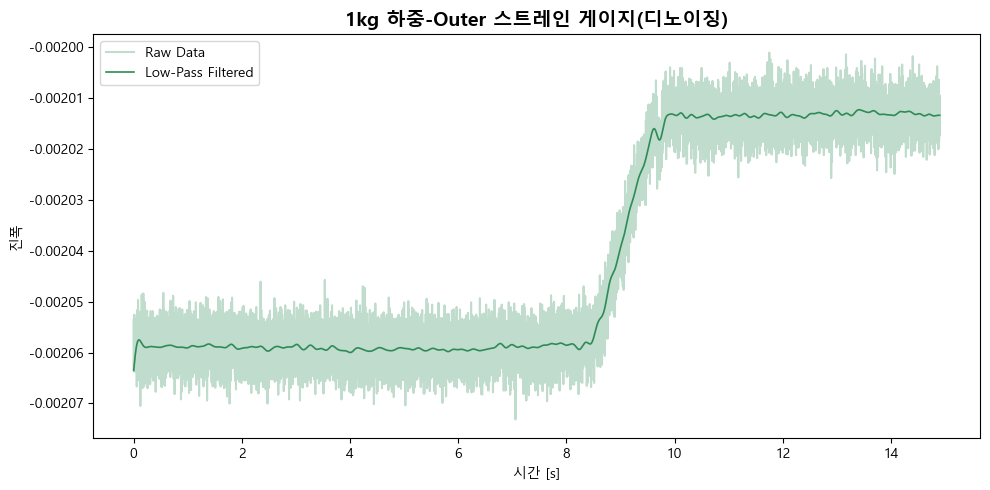

In [85]:
# 로우패스 필터
dt = outer_1kg['시간'].diff().mean()
fs = 1 / dt
cutoff = 5.0
order = 4

nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='low', analog=False)

outer_1kg['진폭_로우패스'] = filtfilt(b, a, outer_1kg['진폭'])

# 2. 그래프 
plt.figure(figsize=(10, 5))
plt.plot(outer_1kg['시간'], outer_1kg['진폭'], color='seagreen', alpha=0.3, label='Raw Data')
plt.plot(outer_1kg['시간'], outer_1kg['진폭_로우패스'], color='seagreen', linewidth=1.2, label='Low-Pass Filtered')

plt.title('1kg 하중-Outer 스트레인 게이지(디노이징)', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]')
plt.ylabel('진폭')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
# 평균값 계산
V_unloaded = outer_1kg[(outer_1kg['시간'] >= 0) & (outer_1kg['시간'] <= 7)]['진폭_로우패스'].mean()
V_loaded = outer_1kg[(outer_1kg['시간'] >= 11) & (outer_1kg['시간'] <= 13)]['진폭_로우패스'].mean()

print(f"V_unloaded (0~7초, Denoised) | {V_unloaded:.6f}")
print(f"V_loaded (11~13초, Denoised) | {V_loaded:.6f}")
print(f"delta_V                      | {V_loaded-V_unloaded:.9f}")

V_unloaded (0~7초, Denoised) | -0.002059
V_loaded (11~13초, Denoised) | -0.002013
delta_V                      | 0.000045831


### **Unknown 추 측정값 - Inner 스트레인 게이지**

Inner 스트레인 게이지 분석

In [87]:
outer_unknown = pd.read_excel("D:/00 기계공학실험/고체 생산/Straingage_outer_unknown.xlsx")
inner_unknown = pd.read_excel("D:/00 기계공학실험/고체 생산/Straingage_inner_unknown.xlsx")
outer_unknown.rename(columns = {'시간 - SC1Mod2/ai1':'시간','진폭 - SC1Mod2/ai1':'진폭'}, inplace=True)
inner_unknown.rename(columns = {'시간 - SC1Mod2/ai3':'시간','진폭 - SC1Mod2/ai3':'진폭'}, inplace=True)

display(outer_unknown.head())
display(inner_unknown.head())

,시간,진폭
0,오후 4:42:21.415 2025-11-03,-0.002059
1,오후 4:42:21.416 2025-11-03,-0.002059
2,오후 4:42:21.417 2025-11-03,-0.002060
3,오후 4:42:21.418 2025-11-03,-0.002066
4,오후 4:42:21.419 2025-11-03,-0.002064


,시간,진폭
0,오후 4:42:19.714 2025-11-03,-0.000126
1,오후 4:42:19.715 2025-11-03,-0.000119
2,오후 4:42:19.716 2025-11-03,-0.000116
3,오후 4:42:19.717 2025-11-03,-0.000126
4,오후 4:42:19.718 2025-11-03,-0.000130


In [88]:
inner_unknown['시간'] = inner_unknown['시간'].apply(extract_time)
inner_unknown['시간'] = pd.to_timedelta(inner_unknown['시간']).dt.total_seconds()
inner_unknown['시간'] = inner_unknown['시간'] - inner_unknown['시간'].iloc[0]
inner_unknown['진폭'] = inner_unknown['진폭'].astype(float)

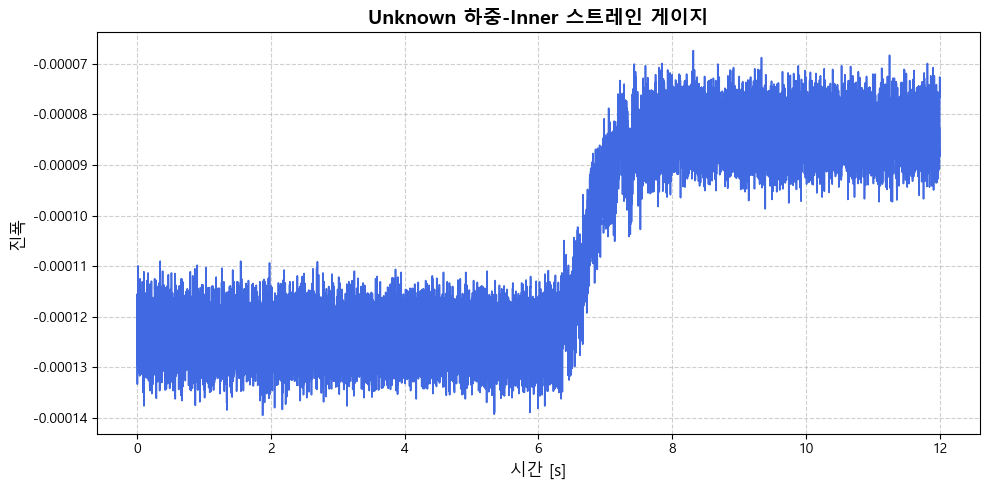

In [89]:
# 그래프 도식화 (원본raw)
plt.figure(figsize=(10, 5))
plt.plot(inner_unknown['시간'], inner_unknown['진폭'], color='royalblue', linewidth=1.2)

plt.title('Unknown 하중-Inner 스트레인 게이지', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]', fontsize=12)
plt.ylabel('진폭', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [90]:
# 전압 평균값 계산
V_unloaded = inner_unknown[(inner_unknown['시간'] >= 0) & (inner_unknown['시간'] <= 5)]['진폭'].mean()
V_loaded = inner_unknown[(inner_unknown['시간'] >= 9) & (inner_unknown['시간'] <= 12)]['진폭'].mean()

print(f"V_unloaded (0~5초 평균) | {V_unloaded:.8f}")
print(f"V_loaded (9~12초 평균)  | {V_loaded:.9f}")

V_unloaded (0~5초 평균) | -0.00012378
V_loaded (9~12초 평균)  | -0.000083429


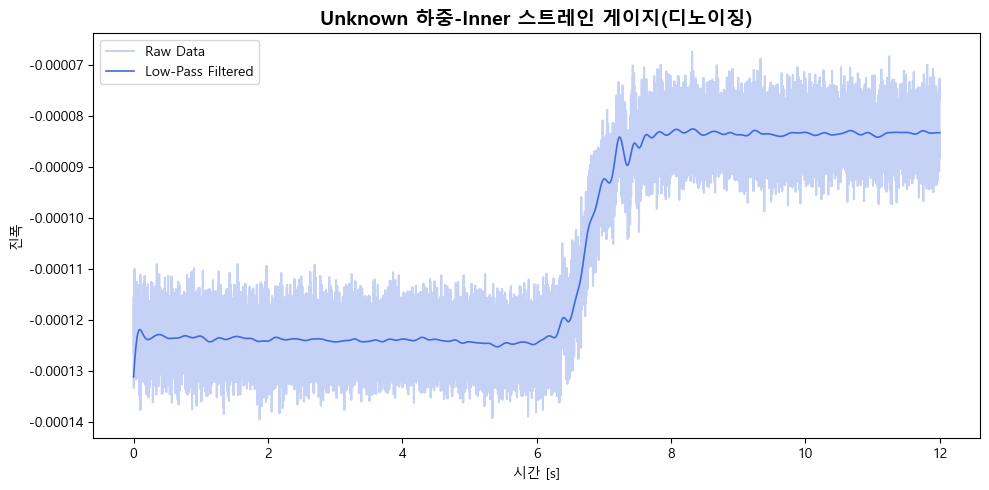

In [91]:
# 로우패스 필터
dt = inner_unknown['시간'].diff().mean()
fs = 1 / dt
cutoff = 5.0
order = 4

nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='low', analog=False)

inner_unknown['진폭_로우패스'] = filtfilt(b, a, inner_unknown['진폭'])

# 2. 그래프 
plt.figure(figsize=(10, 5))
plt.plot(inner_unknown['시간'], inner_unknown['진폭'], color='royalblue', alpha=0.3, label='Raw Data')
plt.plot(inner_unknown['시간'], inner_unknown['진폭_로우패스'], color='royalblue', linewidth=1.2, label='Low-Pass Filtered')

plt.title('Unknown 하중-Inner 스트레인 게이지(디노이징)', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]')
plt.ylabel('진폭')
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
# 전압 평균값 계산
V_unloaded = inner_unknown[(inner_unknown['시간'] >= 0) & (inner_unknown['시간'] <= 5)]['진폭_로우패스'].mean()
V_loaded = inner_unknown[(inner_unknown['시간'] >= 9) & (inner_unknown['시간'] <= 12)]['진폭_로우패스'].mean()

print(f"V_unloaded (0~5초, Denoised) | {V_unloaded:.7f}")
print(f"V_loaded (9~12초, Denoised)  | {V_loaded:.9f}")
print(f"delta_V                      | {V_loaded-V_unloaded:.9f}")

V_unloaded (0~5초, Denoised) | -0.0001238
V_loaded (9~12초, Denoised)  | -0.000083436
delta_V                      | 0.000040367


### **Unknown 추 측정값 - Outer 스트레인 게이지**

Outer 스트레인 게이지 분석

In [93]:
outer_unknown['시간'] = outer_unknown['시간'].apply(extract_time)
outer_unknown['시간'] = pd.to_timedelta(outer_unknown['시간']).dt.total_seconds()
outer_unknown['시간'] = outer_unknown['시간'] - outer_unknown['시간'].iloc[0]
outer_unknown['진폭'] = outer_unknown['진폭'].astype(float)

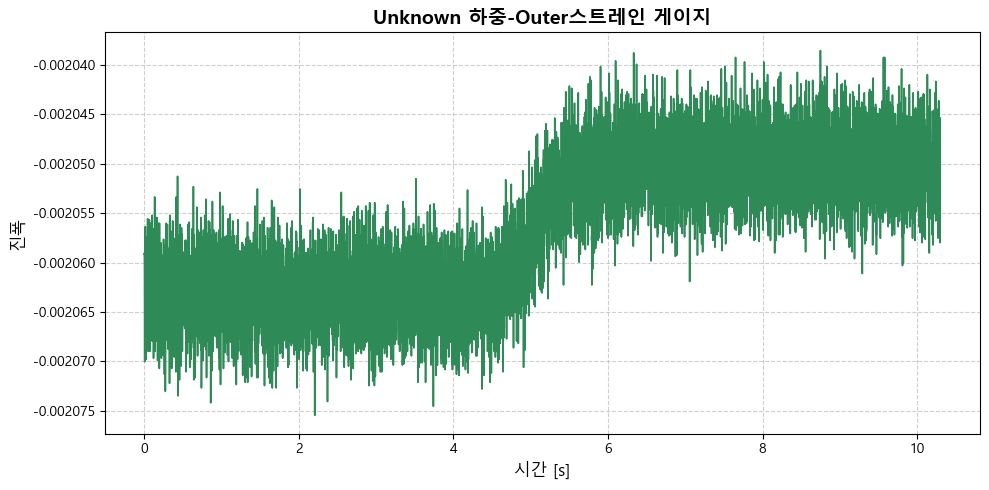

In [94]:
# 그래프(원본raw)
plt.figure(figsize=(10, 5))
plt.plot(outer_unknown['시간'], outer_unknown['진폭'], color='seagreen', linewidth=1.2)

plt.title('Unknown 하중-Outer스트레인 게이지', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]', fontsize=12)
plt.ylabel('진폭', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [95]:
# 평균값 계산
V_unloaded = outer_unknown[(outer_unknown['시간'] >= 0) & (outer_unknown['시간'] <= 4)]['진폭'].mean()
V_loaded = outer_unknown[(outer_unknown['시간'] >= 7) & (outer_unknown['시간'] <= 10)]['진폭'].mean()

print(f"V_unloaded (0~4초 평균) | {V_unloaded:.6f}")
print(f"V_loaded (7~10초 평균)  | {V_loaded:.6f}")

V_unloaded (0~4초 평균) | -0.002063
V_loaded (7~10초 평균)  | -0.002050


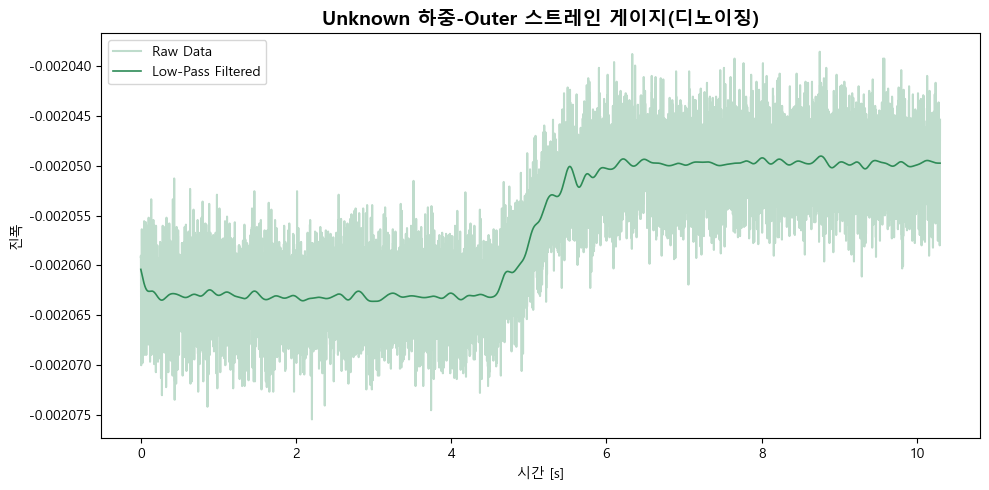

In [96]:
# 로우패스 필터
dt = outer_unknown['시간'].diff().mean()
fs = 1 / dt
cutoff = 5.0
order = 4

nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='low', analog=False)

outer_unknown['진폭_로우패스'] = filtfilt(b, a, outer_unknown['진폭'])

# 2. 그래프 
plt.figure(figsize=(10, 5))
plt.plot(outer_unknown['시간'], outer_unknown['진폭'], color='seagreen', alpha=0.3, label='Raw Data')
plt.plot(outer_unknown['시간'], outer_unknown['진폭_로우패스'], color='seagreen', linewidth=1.2, label='Low-Pass Filtered')

plt.title('Unknown 하중-Outer 스트레인 게이지(디노이징)', fontsize=14, fontweight='bold')
plt.xlabel('시간 [s]')
plt.ylabel('진폭')
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# 평균값 계산
V_unloaded = outer_unknown[(outer_unknown['시간'] >= 0) & (outer_unknown['시간'] <= 4)]['진폭_로우패스'].mean()
V_loaded = outer_unknown[(outer_unknown['시간'] >= 7) & (outer_unknown['시간'] <= 10)]['진폭_로우패스'].mean()

print(f"V_unloaded (0~4초, Denoised) | {V_unloaded:.6f}")
print(f"V_loaded (7~10초, Denoised)  | {V_loaded:.6f}")
print(f"delta_V                      | {V_loaded-V_unloaded:.9f}")

V_unloaded (0~4초, Denoised) | -0.002063
V_loaded (7~10초, Denoised)  | -0.002050
delta_V                      | 0.000013348
